# EccoPy-2D-V — vertical cross-sections

`eccopy2d_v` classifies a **vertical** slice of reflectivity, shaped `(Z, X)`:
an RHI, a gridded cross-section, or a column-vs-time curtain.

The pipeline is three stages:

```
reflectivity  ──▶  texture  ──▶  convectivity  ──▶  echo type
                (variability      (0–1 score)      (14/16/18 stratiform,
                 in a sliding                       25 mixed,
                 window along X)                    32/34/36/38 convective)
```

2-D-V is the only module that produces **sub-classified** output from a
vertical slice: given `height`, `temp`, and `melt`, it splits stratiform
into low/mid/high and convective into elevated/shallow/mid/deep. Without
those it returns basic codes (1 stratiform / 2 mixed / 3 convective).

This notebook walks the whole chain on a real scan, shows every
intermediate array, documents every tunable parameter, and ends with a
reusable tool for exploring parameters on your own data.

In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

from eccopy import eccopy2d_v, stats
from eccopy.params import WindowSpec, TextureParams, ClassificationParams
from eccopy.core.temperature import broadcast_temp_field, melt_layer_from_temp
from eccopy.core.colormaps import (
    echo_type_cmap, echo_type_norm, ECHO_TYPE_LABELS,
    basic_echo_type_cmap, basic_echo_type_norm, BASIC_ECHO_TYPE_LABELS,
    convectivity_cmap, convectivity_norm, remap_echo_type,
)

plt.rcParams["figure.dpi"] = 110

## 1. The data

An NSF NCAR S-Pol RHI from PRECIP-2022 (Taiwan), 2022-05-26 17:56 UTC, at
azimuth 264°. The grid is 41 heights × 601 range gates at 250 m spacing,
reaching 10 km altitude and 150 km range.

The file also carries a temperature profile from an EOL sounding launched
42 minutes earlier at the same site — that is what makes sub-classification
possible. See `data/README.md` for provenance and attribution.

In [2]:
ds = nc.Dataset("data/spol_rhi_20220526.nc")

print(ds.title)
print(f"valid time : {ds.valid_time}")
print(f"azimuth    : {ds.azimuth_deg:.1f} deg")
print()
for name, var in ds.variables.items():
    print(f"  {name:22s} {str(var.shape):12s} {var.units}")

S-Pol gridded RHI with co-located sounding, 2022-05-26
valid time : 2022-05-26T17:56:56Z
azimuth    : 263.9 deg

  Z                      (41,)        m
  R                      (601,)       m
  DBZ_F                  (41, 601)    dBZ
  sounding_altitude      (1197,)      m
  sounding_temperature   (1197,)      degC


In [3]:
# EccoPy is array-in / array-out: it never reads files itself. Convert to
# the units EccoPy expects (km) and hand it plain numpy arrays.
z_km = ds.variables["Z"][:] / 1000.0            # (Z,)  height above radar
r_km = ds.variables["R"][:] / 1000.0            # (X,)  ground range
dbz = np.ma.filled(ds.variables["DBZ_F"][:].astype(float), np.nan)   # (Z, X)

sounding_z = ds.variables["sounding_altitude"][:] / 1000.0
sounding_t = ds.variables["sounding_temperature"][:]

print(f"dbz {dbz.shape}: {np.isfinite(dbz).mean():.1%} valid, "
      f"{np.nanmin(dbz):.1f} to {np.nanmax(dbz):.1f} dBZ")

dbz (41, 601): 87.8% valid, -35.5 to 63.6 dBZ


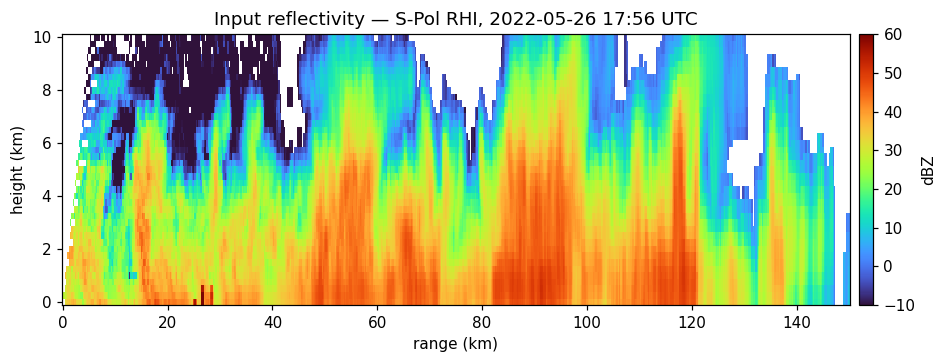

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.2))
m = ax.pcolormesh(r_km, z_km, dbz, cmap="turbo", vmin=-10, vmax=60, shading="nearest")
ax.set_xlabel("range (km)"); ax.set_ylabel("height (km)")
ax.set_title("Input reflectivity — S-Pol RHI, 2022-05-26 17:56 UTC")
fig.colorbar(m, ax=ax, label="dBZ", pad=0.01)
plt.show()

## 2. Auxiliary fields: height, temperature, melt

Sub-classification needs three `(Z, X)` fields alongside the reflectivity.
All three must be passed together — supply only some and `eccopy2d_v`
returns basic 1/2/3 codes instead.

| Field | What it is | How it's used |
|---|---|---|
| `height` | height of each grid point, km | near-surface convective test |
| `temp` | temperature, °C | separates mid from deep/high at −25 °C |
| `melt` | melting-layer indicator | **primary** stratiform/convective sub-type signal, thresholded at 15 |

`melt` is a binary field, not a continuous one: `melt_layer_from_temp()`
returns 20 where temperature ≤ 0 °C and 10 where it is above, matching the
reference MATLAB driver. The threshold of 15 in `class_sub_2d` simply
splits those two values.

In [5]:
# Height varies only with Z here, so broadcast the vertical coordinate
# across range. (For a real elevation-scanning RHI with beam curvature you
# would pass a genuine 2-D height field instead.)
height = np.broadcast_to(z_km[:, None], dbz.shape).copy()

# Interpolate the sounding onto the radar's vertical grid, then broadcast
# the profile across range. broadcast_temp_field() accepts a 1-D profile
# or an already-2-D field.
temp_profile = np.interp(z_km, sounding_z, sounding_t)
temp = broadcast_temp_field(temp_profile, dbz.shape)

# Binary melting-layer field derived from temperature.
melt = melt_layer_from_temp(temp)

freezing_km = np.interp(0.0, -temp_profile, z_km)
print(f"melt field values : {np.unique(melt[np.isfinite(melt)])}")
print(f"0 C level         : {freezing_km:.2f} km")
print(f"-25 C level       : {np.interp(25.0, -temp_profile, z_km):.2f} km")

melt field values : [10. 20.]
0 C level         : 5.20 km
-25 C level       : 9.40 km


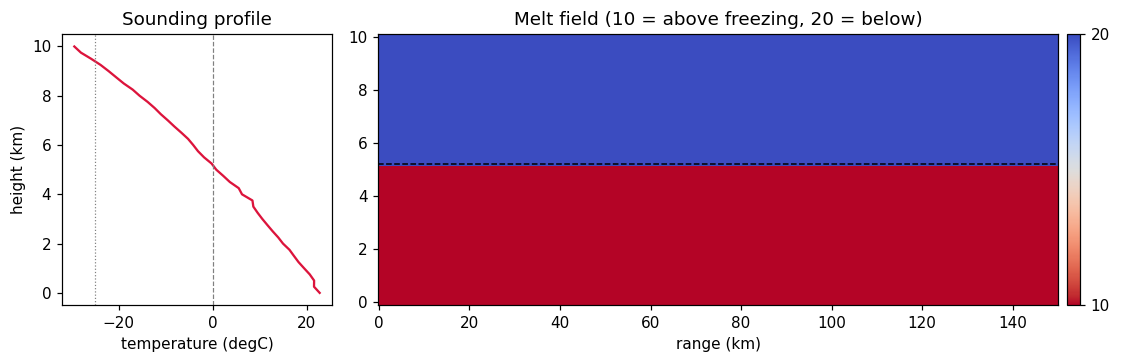

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), width_ratios=[1, 3])

axes[0].plot(temp_profile, z_km, color="crimson")
axes[0].axvline(0, color="0.5", lw=0.8, ls="--")
axes[0].axvline(-25, color="0.5", lw=0.8, ls=":")
axes[0].set_xlabel("temperature (degC)"); axes[0].set_ylabel("height (km)")
axes[0].set_title("Sounding profile")

m = axes[1].pcolormesh(r_km, z_km, melt, cmap="coolwarm_r", shading="nearest")
axes[1].axhline(freezing_km, color="k", lw=1.0, ls="--")
axes[1].set_xlabel("range (km)")
axes[1].set_title("Melt field (10 = above freezing, 20 = below)")
fig.colorbar(m, ax=axes[1], ticks=[10, 20], pad=0.01)
plt.tight_layout(); plt.show()

## 3. Parameters

Every knob `eccopy2d_v` exposes is listed below. The **sensitivity** column
is a rough tier measured on *this* scene — treat it as a guide to where
attention is worth spending, not as a number that transfers to your data.
Section 8 gives you a tool to measure it on your own.

### Texture stage

| Parameter | Direction | Mechanism | Sensitivity |
|---|---|---|---|
| `window` | larger → smoother texture, fewer isolated cells | sets the sliding-window radius along X; a bigger window averages over more range gates, so local spikes matter less | **high** |
| `dbz_base` | shifts what counts as "no echo" | subtracted before the variability statistic, so it moves the floor the texture is measured against | **high** |
| `min_valid_dbz` | higher → weak echo dropped before texture | values below it become missing, so they stop contributing as neighbours in the window | **high** |
| `texture_limit_high` | higher → lower convectivity everywhere | this is the **normaliser**: convectivity = texture / `texture_limit_high`, clipped to 1. Halving it roughly doubles convectivity | **high** |
| `kernel_mode` | `"uniform"` vs `"varying"` window resolution | `"uniform"` resolves one radius from the median spacing; `"varying"` resolves per point. Identical on evenly-spaced grids | **low** here (spacing is uniform) |

### Classification stage

| Parameter | Direction | Mechanism | Sensitivity |
|---|---|---|---|
| `min_convectivity_for_convective` | higher → less convective area | convectivity at or above this seeds convective regions; raising it starves them from the edges inward | **high** |
| `max_convectivity_for_stratiform` | higher → more stratiform, less mixed | convectivity below this is stratiform; the band between the two thresholds is "mixed" | **moderate** |
| `enlarge_conv` | larger → convective regions grow and merge | radius of the morphological closing applied to convective regions before sub-typing | **high** |
| `enlarge_mixed` | larger → mixed regions grow and merge | same, for mixed regions | **moderate** |
| `surf_alt_lim` | raises the near-surface cutoff | the near-surface convective test is `echo base < 500 m + surf_alt_lim`; convection based above that is *elevated* (32) rather than surface-based. Also gates `remove_surface_echo` | **low** here (this scene's convection reaches the ground) |
| `remove_surface_echo` | drops echo below `surf_alt_lim` before texture | reproduces the reference driver's ground-clutter masking; off by default | **low** here |

The two convectivity thresholds must satisfy
`max_convectivity_for_stratiform <= min_convectivity_for_convective`; the
gap between them is exactly the mixed category.

In [7]:
# --- texture stage -------------------------------------------------------
window = WindowSpec((7, "km"))     # physical radius; resolved against spacing
                                   # WindowSpec(28) would be 28 pixels instead

texture_params = TextureParams(
    dbz_base=0.0,                  # reflectivity floor subtracted pre-texture
    texture_limit_high=30.0,       # convectivity normaliser (see table above)
    min_valid_dbz=None,            # None = module default; here, no gating,
                                   # matching f_reflTexture.m. Set a number to
                                   # drop weak echo before texture.
)

# --- classification stage ------------------------------------------------
class_params = ClassificationParams(
    max_convectivity_for_stratiform=0.4,   # below this -> stratiform
    min_convectivity_for_convective=0.5,   # at/above this -> convective
                                           # between the two -> mixed
    enlarge_mixed=5,                       # closing radius, mixed regions
    enlarge_conv=5,                        # closing radius, convective regions
    surf_alt_lim=0.0,                      # metres; near-surface cutoff
)

print(f"texture window : {window}")
print(f"convectivity bands: stratiform < "
      f"{class_params.max_convectivity_for_stratiform} <= mixed < "
      f"{class_params.min_convectivity_for_convective} <= convective")

texture window : WindowSpec(7, 'km')
convectivity bands: stratiform < 0.4 <= mixed < 0.5 <= convective


## 4. Running the classifier

`return_intermediates=True` additionally populates `fitted_dbz`,
`detrended_dbz`, and `echo_basic`, so you can inspect why a point ended up
where it did. It costs nothing when left off.

In [8]:
result = eccopy2d_v.run(
    dbz,
    coords_z=z_km,
    coords_x=r_km,
    height=height,
    temp=temp,
    melt=melt,
    window=window,
    texture_params=texture_params,
    class_params=class_params,
    kernel_mode="uniform",
    remove_surface_echo=False,
    return_intermediates=True,
)

for name in ("texture", "convectivity", "echo_basic", "echo_type",
             "fitted_dbz", "detrended_dbz"):
    arr = getattr(result, name)
    print(f"  {name:14s} {str(arr.shape):10s} "
          f"{np.isfinite(arr).mean():6.1%} finite")

  texture        (41, 601)   87.8% finite
  convectivity   (41, 601)   87.8% finite
  echo_basic     (41, 601)   87.8% finite
  echo_type      (41, 601)   87.8% finite
  fitted_dbz     (41, 601)  100.0% finite
  detrended_dbz  (41, 601)   87.8% finite


## 5. Stage one — texture

Texture measures how much reflectivity *varies* within the sliding window,
after a local linear trend is removed. Convection is spatially rough;
stratiform rain is smooth. The detrending is what stops a broad, uniform
gradient from registering as roughness.

`fitted_dbz` is the local linear fit at each point, and `detrended_dbz` is
what remains once that fit is removed — the quantity that actually gets
squared into the texture statistic.

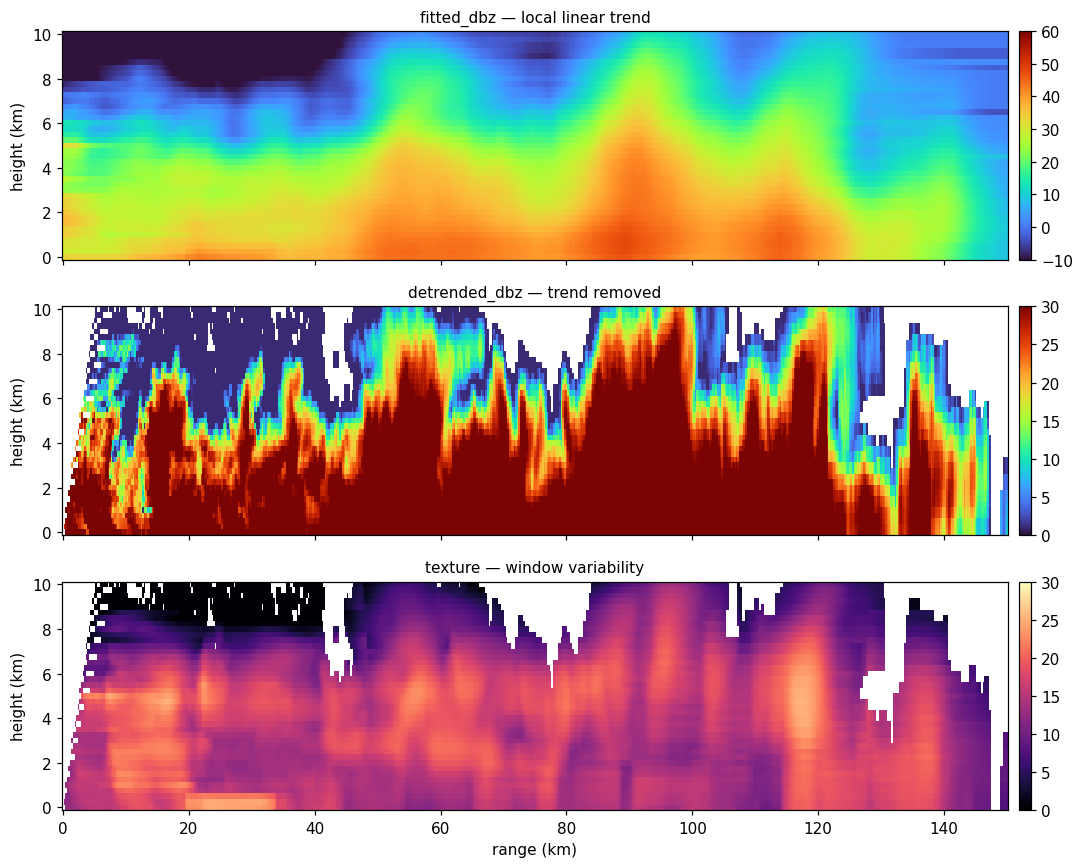

texture: median 15.0, 90th pct 19.9, max 25.3


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, sharey=True)

for ax, field, title, kw in [
    (axes[0], result.fitted_dbz, "fitted_dbz — local linear trend",
     dict(cmap="turbo", vmin=-10, vmax=60)),
    (axes[1], result.detrended_dbz, "detrended_dbz — trend removed",
     dict(cmap="turbo", vmin=0, vmax=30)),
    (axes[2], result.texture, "texture — window variability",
     dict(cmap="magma", vmin=0, vmax=30)),
]:
    m = ax.pcolormesh(r_km, z_km, field, shading="nearest", **kw)
    ax.set_title(title, fontsize=10); ax.set_ylabel("height (km)")
    fig.colorbar(m, ax=ax, pad=0.01)

axes[-1].set_xlabel("range (km)")
plt.tight_layout(); plt.show()

print(f"texture: median {np.nanmedian(result.texture):.1f}, "
      f"90th pct {np.nanpercentile(result.texture, 90):.1f}, "
      f"max {np.nanmax(result.texture):.1f}")

## 6. Stage two — convectivity

Convectivity rescales texture onto 0–1 by dividing by `texture_limit_high`
and clipping. That single line is worth internalising:

```
convectivity = min(texture / texture_limit_high, 1)
```

With the default of 30, a texture of 15 gives exactly 0.5. It also means an
error of `e` in texture produces an error of `e / 30` in convectivity —
useful when reasoning about how input noise propagates.

The colormap below is deliberately discontinuous: it breaks at the two
classification thresholds, so you can read the eventual class boundaries
directly off the convectivity field.

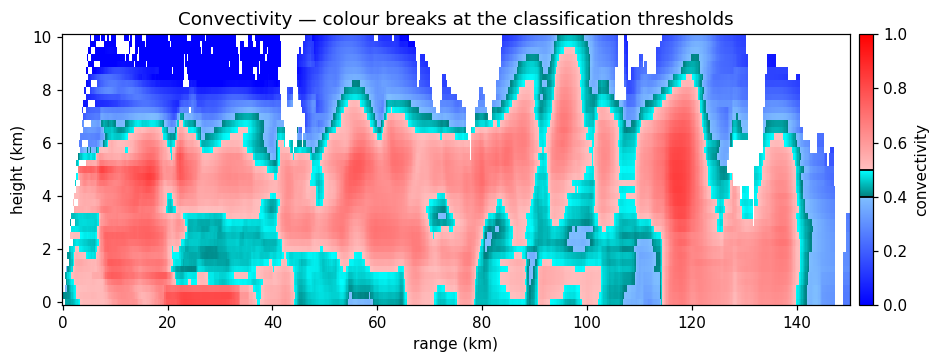

In [10]:
cmap = convectivity_cmap(
    strat_mixed=class_params.max_convectivity_for_stratiform,
    mixed_conv=class_params.min_convectivity_for_convective,
)

fig, ax = plt.subplots(figsize=(11, 3.2))
m = ax.pcolormesh(r_km, z_km, result.convectivity, cmap=cmap,
                  norm=convectivity_norm(), shading="nearest")
ax.set_xlabel("range (km)"); ax.set_ylabel("height (km)")
ax.set_title("Convectivity — colour breaks at the classification thresholds")
cb = fig.colorbar(m, ax=ax, pad=0.01, label="convectivity")
for v in (class_params.max_convectivity_for_stratiform,
          class_params.min_convectivity_for_convective):
    cb.ax.axhline(v, color="k", lw=1.2)
plt.show()

## 7. Stage three — classification

Two steps happen here. First convectivity is thresholded into basic
categories and cleaned up morphologically, giving `echo_basic` (1/2/3).
Then `melt`, `temp`, and `height` split those into sub-types.

Codes are not sequential — they come straight from the reference
implementation. Use `remap_echo_type()` to turn them into contiguous
indices for plotting.

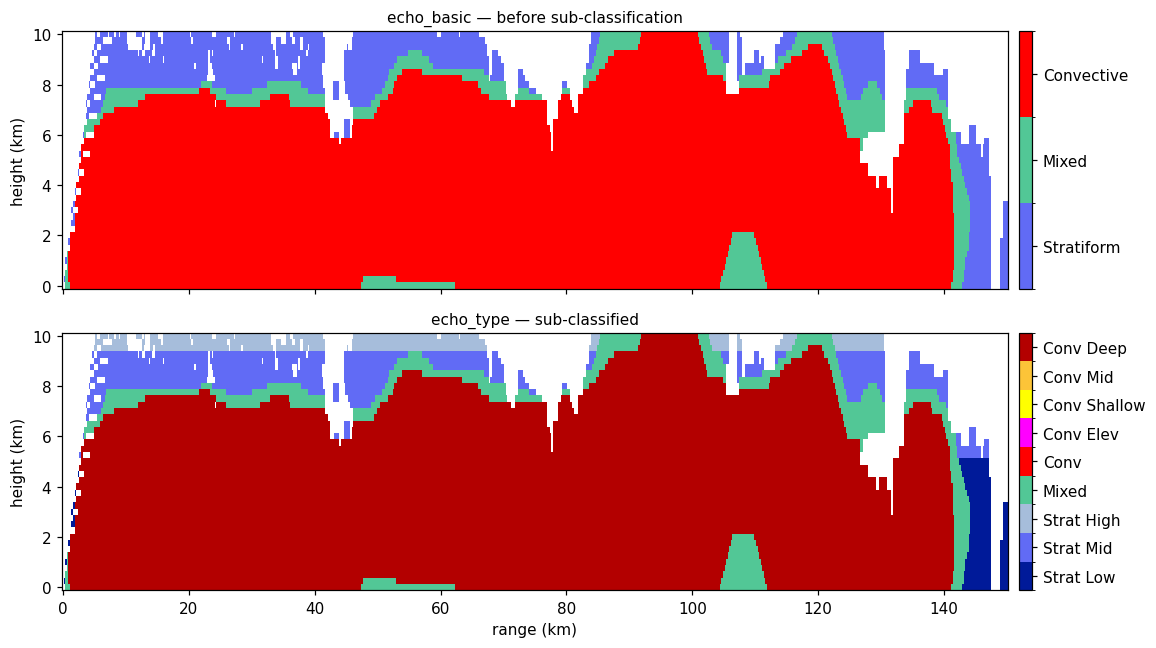

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, sharey=True)

m0 = axes[0].pcolormesh(r_km, z_km, remap_echo_type(result.echo_basic),
                        cmap=basic_echo_type_cmap(), norm=basic_echo_type_norm(),
                        shading="nearest")
axes[0].set_title("echo_basic — before sub-classification", fontsize=10)
cb0 = fig.colorbar(m0, ax=axes[0], ticks=range(1, 4), pad=0.01)
cb0.ax.set_yticklabels(BASIC_ECHO_TYPE_LABELS)

m1 = axes[1].pcolormesh(r_km, z_km, remap_echo_type(result.echo_type),
                        cmap=echo_type_cmap(), norm=echo_type_norm(),
                        shading="nearest")
axes[1].set_title("echo_type — sub-classified", fontsize=10)
cb1 = fig.colorbar(m1, ax=axes[1], ticks=range(1, 10), pad=0.01)
cb1.ax.set_yticklabels(ECHO_TYPE_LABELS)

for ax in axes:
    ax.set_ylabel("height (km)")
axes[-1].set_xlabel("range (km)")
plt.tight_layout(); plt.show()

In [12]:
# Which codes are present, and how much of the classified area each holds.
codes, counts = np.unique(result.echo_type[np.isfinite(result.echo_type)],
                          return_counts=True)
for code, n in zip(codes.astype(int), counts):
    print(f"  {code:3d}  {n / counts.sum():6.1%}")

   14    1.8%
   16    8.1%
   18    3.6%
   25    7.9%
   38   78.6%


### The whole chain in one figure

EccoPy deliberately ships no plotting functions: every output array has
the same shape as the reflectivity you passed in, so your existing
plotting code already works. What it *does* provide is `core.colormaps`,
so the arrays render correctly.

Here is the whole pipeline as one figure — a reasonable thing to copy
into your own code.

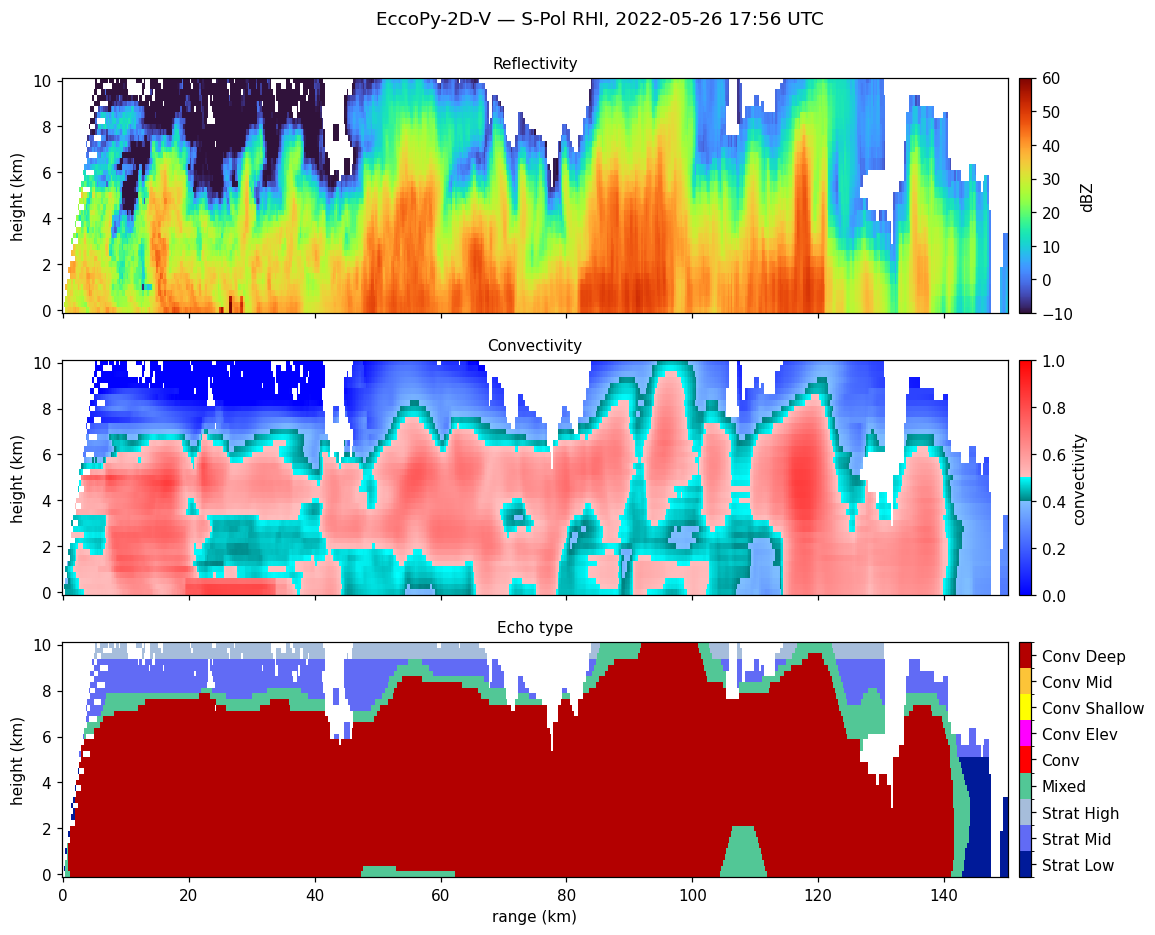

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True, sharey=True)

m = axes[0].pcolormesh(r_km, z_km, dbz, cmap="turbo", vmin=-10, vmax=60,
                       shading="nearest")
fig.colorbar(m, ax=axes[0], pad=0.01, label="dBZ")
axes[0].set_title("Reflectivity", fontsize=10)

m = axes[1].pcolormesh(r_km, z_km, result.convectivity, cmap=cmap,
                       norm=convectivity_norm(), shading="nearest")
fig.colorbar(m, ax=axes[1], pad=0.01, label="convectivity")
axes[1].set_title("Convectivity", fontsize=10)

m = axes[2].pcolormesh(r_km, z_km, remap_echo_type(result.echo_type),
                       cmap=echo_type_cmap(), norm=echo_type_norm(),
                       shading="nearest")
cb = fig.colorbar(m, ax=axes[2], ticks=range(1, 10), pad=0.01)
cb.ax.set_yticklabels(ECHO_TYPE_LABELS)
axes[2].set_title("Echo type", fontsize=10)

for ax in axes:
    ax.set_ylabel("height (km)")
axes[-1].set_xlabel("range (km)")
fig.suptitle("EccoPy-2D-V — S-Pol RHI, 2022-05-26 17:56 UTC", y=0.995)
plt.tight_layout(); plt.show()

## 8. Statistics

`eccopy.stats` works on any classified array. Functions taking a `height`
argument need the vertical axis, so they apply to 2-D-V and 3-D but not to
horizontal or 1-D output.

In [14]:
fractions = stats.echo_type_fractions(result.echo_type)

# Note: this dict mixes a COUNT (n_valid) with fractions -- format accordingly.
print(f"classified pixels : {fractions['n_valid']}")
for name in ("stratiform", "mixed", "convective"):
    print(f"  {name:12s} {fractions[name]:6.1%}")

print(f"\nconvective  {stats.convective_percentage(result.echo_type):5.1f}%")
print(f"stratiform  {stats.stratiform_percentage(result.echo_type):5.1f}%")
print(f"mixed       {stats.mixed_percentage(result.echo_type):5.1f}%")

classified pixels : 21625
  stratiform    13.5%
  mixed          7.9%
  convective    78.6%

convective   78.6%
stratiform   13.5%
mixed         7.9%


In [15]:
# Connected convective regions. Note this labels the FINAL echo_type field,
# so it will not match a clump count computed earlier in the pipeline.
sizes = stats.clump_sizes(result.echo_type, category="convective")
print(f"convective regions : {stats.n_clumps(result.echo_type, 'convective')}")
if len(sizes):
    print(f"  largest {int(sizes.max())} px, median {int(np.median(sizes))} px")

# Height statistics need the vertical axis (axis=0 for a (Z, X) array).
top = stats.convective_top_height(result.echo_type, height, axis=0)
depth = stats.convective_depth(result.echo_type, height, axis=0)
if np.isfinite(top).any():
    print(f"\nconvective top   : mean {np.nanmean(top):.1f} km, "
          f"max {np.nanmax(top):.1f} km")
    print(f"convective depth : mean {np.nanmean(depth):.1f} km")

convective regions : 1
  largest 16998 px, median 16998 px

convective top   : mean 7.4 km, max 10.0 km
convective depth : mean 7.3 km


In [16]:
# summarize() rolls the common ones into a single dict.
for key, value in stats.summarize(result.echo_type, height=height, axis=0).items():
    if isinstance(value, float):
        print(f"  {key:28s} {value:.3f}")
    else:
        print(f"  {key:28s} {value}")

  n_valid                      21625
  stratiform                   0.135
  mixed                        0.079
  convective                   0.786
  convective_pct               78.603
  stratiform_pct               13.526
  mixed_pct                    7.871
  n_convective_clumps          1
  n_stratiform_clumps          25
  convective_clump_sizes       [16998.]
  mean_convective_clump_size   16998.000
  mean_convective_top_height   7.430
  mean_convective_base_height  0.126
  mean_convective_depth        7.304
  max_convective_top_height    10.000


## 9. Exploring parameters yourself

The sensitivity tiers in section 3 were measured on this one scene. Rather
than trusting them, measure the ones you care about on your own data.

The helper below re-runs the classifier across a list of values for any
parameter and reports how much of the classified field changes. Point it at
whichever knob you are unsure about.

In [17]:
from dataclasses import replace

CLASSIFIED = [14, 16, 18, 25, 30, 32, 34, 36, 38, 1, 2, 3]

BASE = dict(coords_z=z_km, coords_x=r_km, height=height, temp=temp, melt=melt,
            window=window, texture_params=texture_params,
            class_params=class_params)


def sweep(values, make_kwargs, label=""):
    """Re-run with each value and report disagreement against the baseline.

    make_kwargs(value) -> dict of run() overrides. Use dataclasses.replace()
    to change one field of a params object and leave the rest alone --
    rebuilding the dataclass by hand silently resets every field you omit.

    The reported percentage counts changes to the full echo-type CODE, so a
    region that stays convective but shifts from deep (38) to mid (36)
    counts as changed.
    """
    reference = eccopy2d_v.run(dbz, **BASE).echo_type
    ref_mask = np.isin(reference, CLASSIFIED)

    print(f"{label}")
    for value in values:
        echo = eccopy2d_v.run(dbz, **{**BASE, **make_kwargs(value)}).echo_type
        mask = ref_mask | np.isin(echo, CLASSIFIED)
        changed = 100 * (1 - (reference[mask] == echo[mask]).mean())
        conv = stats.convective_percentage(echo)
        print(f"  {str(value):>8s}  {changed:5.1f}% of pixels changed"
              f"   convective area {conv:5.1f}%")


sweep([3, 5, 7, 11],
      lambda v: dict(window=WindowSpec((v, "km"))),
      label="window radius (km)")

window radius (km)


         3   24.2% of pixels changed   convective area  61.4%


         5    9.6% of pixels changed   convective area  73.0%


         7    0.0% of pixels changed   convective area  78.6%


        11    9.9% of pixels changed   convective area  84.0%


In [18]:
sweep([20.0, 30.0, 40.0],
      lambda v: dict(texture_params=replace(texture_params, texture_limit_high=v)),
      label="texture_limit_high — the convectivity normaliser")

sweep([0.45, 0.50, 0.60],
      lambda v: dict(class_params=replace(class_params,
                                          min_convectivity_for_convective=v)),
      label="min_convectivity_for_convective")

texture_limit_high — the convectivity normaliser


      20.0   15.8% of pixels changed   convective area  91.2%


      30.0    0.0% of pixels changed   convective area  78.6%


      40.0   86.5% of pixels changed   convective area  27.9%


min_convectivity_for_convective


      0.45    5.2% of pixels changed   convective area  83.8%


       0.5    0.0% of pixels changed   convective area  78.6%


       0.6   78.6% of pixels changed   convective area  56.4%


## Where to go next

- `eccopy1d` — the same texture/convectivity chain on a 1-D series
- `eccopy2d_h` — horizontal composites, with clumping instead of morphology
- `eccopy3d` — full volumes, sub-typed by clump geometry

Parameter reference and algorithm sources are in the top-level `README.md`.
Contributions are welcome — see `CONTRIBUTING.md`, particularly the
ground-truth standard for any change to the classification path.